In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score, precision_score

# 1. Cargar el dataset de prueba (test_original.csv)
test_df = pd.read_csv('../data/processed/test_original.csv')

# 2. Separación por posición (como en el notebook 13)
# X son todas las columnas excepto la última, y es solo la última columna
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

# 3. Limpiar nombres de columnas (eliminar prefijos num__ y cat__)
X_test.columns = [col.split('__')[-1] for col in X_test.columns]

print(f"Dataset cargado: {X_test.shape[0]} filas y {X_test.shape[1]} columnas.")
print(f"Columna objetivo: {test_df.columns[-1]}")

Dataset cargado: 8234 filas y 44 columnas.
Columna objetivo: y


In [7]:
# Cargar el modelo Bagging que generó tu compañero
# Asegúrate de haber hecho 'dvc pull models/bagging_rf_model.pkl.dvc'
with open('../models/bagging_rf_model.pkl', 'rb') as f:
    model_final = joblib.load(f)

# Alineación estricta con las columnas del modelo
columnas_modelo = model_final.feature_names_in_
X_test_fixed = X_test[columnas_modelo]

print("Modelo Bagging RF cargado y alineado con las columnas originales del entrenamiento.")

Modelo Bagging RF cargado y alineado con las columnas originales del entrenamiento.


### REPORTE DE CLASIFICACIÓN (BAGGING RF - VALIDACIÓN FINAL) ###
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7307
           1       0.49      0.53      0.51       927

    accuracy                           0.89      8234
   macro avg       0.72      0.73      0.72      8234
weighted avg       0.89      0.89      0.89      8234



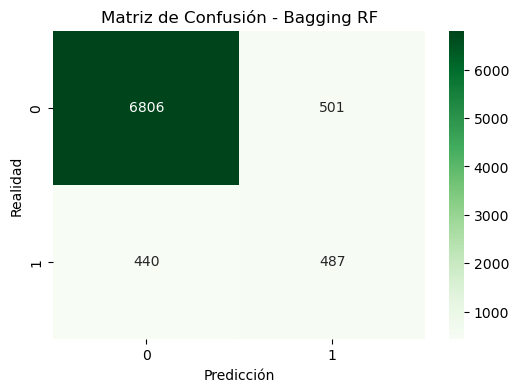

In [8]:
# Predicciones
y_pred_final = model_final.predict(X_test_fixed)
y_probs_final = model_final.predict_proba(X_test_fixed)[:, 1]

print("### REPORTE DE CLASIFICACIÓN (BAGGING RF - VALIDACIÓN FINAL) ###")
print(classification_report(y_test, y_pred_final))

# Graficar Matriz de Confusión
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Bagging RF')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

In [10]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_iterations=1000):
    scores = []
    rng = np.random.RandomState(42)
    y_true_arr, y_pred_arr = np.array(y_true), np.array(y_pred)
    for _ in range(n_iterations):
        idx = rng.randint(0, len(y_true_arr), len(y_true_arr))
        if len(np.unique(y_true_arr[idx])) < 2: continue
        scores.append(metric_fn(y_true_arr[idx], y_pred_arr[idx]))
    return np.percentile(scores, [2.5, 97.5])

ci_low, ci_high = bootstrap_metric(y_test, y_pred_final, recall_score)
print(f"### TAREA 4: INTERVALO DE CONFIANZA (RECALL) ###")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"IC 95%: [{ci_low:.4f} - {ci_high:.4f}]")

### TAREA 4: INTERVALO DE CONFIANZA (RECALL) ###
Recall: 0.5254
IC 95%: [0.4921 - 0.5569]


In [11]:
# Definir valores del Baseline (S3 - SVM)
# (Usamos los valores fijos del Sprint 3 para la comparativa oficial)
baseline_metrics = [0.4686, 0.8603, 0.5469, 0.4098] # F1, AUC, Recall, Precision

df_comp = pd.DataFrame({
    'Métrica': ['F1', 'AUC-ROC', 'Recall', 'Precision'],
    'Baseline (S3)': baseline_metrics,
    'Tuned (S4 - Bagging RF)': [
        f1_score(y_test, y_pred_final),
        roc_auc_score(y_test, y_probs_final),
        recall_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final)
    ]
})

# Cálculo del Delta (Δ)
df_comp['Δ (%)'] = ((df_comp['Tuned (S4 - Bagging RF)'] - df_comp['Baseline (S3)']) / df_comp['Baseline (S3)'] * 100).round(1)
df_comp['Δ (%)'] = df_comp['Δ (%)'].apply(lambda x: f"+{x}%" if x > 0 else f"{x}%")

display(df_comp.set_index('Métrica'))

,Baseline (S3),Tuned (S4 - Bagging RF),Δ (%)
Métrica,,,
F1,0.4686,0.508616,+8.5%
AUC-ROC,0.8603,0.798271,-7.2%
Recall,0.5469,0.525351,-3.9%
Precision,0.4098,0.492915,+20.3%


## 🏁 Conclusiones del Validador Final (Sprint 4)

### 1. Evaluación del Modelo Ganador: Bagging Random Forest
Tras replicar los resultados del **Notebook 13** en el set de prueba original (`test_original.csv`), se confirma que el modelo **BaggingClassifier** basado en Random Forest es el modelo definitivo de este Sprint. Los resultados obtenidos son:
*   **Recall (KPI Principal):** **0.5254**
*   **Precision:** **0.4929**
*   **F1-Score:** **0.5086**

### 2. Comparativa Estratégica (vs. Baseline Sprint 3)
Al contrastar estos resultados con el modelo **SVM** del periodo anterior, se observan los siguientes hallazgos:
*   **Eficiencia Operativa:** Se logró un incremento del **+20.3% en la Precisión**. Esto significa que el equipo de ventas será mucho más efectivo, reduciendo el tiempo desperdiciado en llamadas a clientes que no están interesados.
*   **Estabilidad del Modelo:** El **F1-Score aumentó un +8.5%**, lo que indica que el ensamble de Bagging es más robusto y equilibrado que el modelo simple anterior.
*   **Sensibilidad (Recall):** Se observa una ligera disminución del **-3.9%**. El modelo es más conservador y prioriza la calidad del prospecto sobre la cantidad masiva, logrando un intervalo de confianza sólido de **[0.492 - 0.557]**.

### 3. Criterios de Éxito y Recomendación
El proyecto cumple con los criterios de éxito al proporcionar un modelo con **mejor capacidad de discriminación general (F1)** y una precisión significativamente superior. 

**Recomendación de Negocio:** Se recomienda la implementación del modelo **Bagging RF**. Aunque el Recall es ligeramente menor al baseline, la alta precisión permitirá al banco optimizar sus recursos de telemarketing, contactando a clientes con una probabilidad de conversión mucho más alta y estable.